In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
try:
    import statsmodels.stats.api as sms
    from statsmodels.stats.proportion import proportions_ztest
    from statsmodels.stats.multicomp import MultiComparison
except ImportError:  # statsmodels not available in this environment
    sms = None
    proportions_ztest = None
    MultiComparison = None
from scipy.stats import (ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,
                         pearsonr, spearmanr, kendalltau, f_oneway, kruskal)

sns.set_style("whitegrid")


In [2]:
# Import the data (CSV exported from the Kaggle "AB Test Results" dataset)
df = pd.read_csv("AB_Test_Results.csv")
df.head()


   USER_ID VARIANT_NAME  REVENUE
0      564      control      0.0
1     4895      control      0.0
2     4140      variant      0.0
3     2775      variant      0.0
4     2738      control      0.0

# Data Understanding

In [3]:
# DataFrame information
print("=== df.info() ===")
df.info()

# Columns in the DataFrame
print("\n=== Columns ===")
print(df.columns.tolist())

# Counting missing values
print("\n=== Missing values per column ===")
print(df.isnull().sum())

# Descriptive statistics
print("\n=== Descriptive statistics ===")
print(df.describe())

# Value counts for VARIANT_NAME
print("\n=== VARIANT_NAME value counts ===")
print(df["VARIANT_NAME"].value_counts())

# Counting unique users in USER_ID
print("\n=== Unique users ===")
print("Unique USER_ID:", df["USER_ID"].nunique())


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  str    
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 234.5 KB

=== Columns ===
['USER_ID', 'VARIANT_NAME', 'REVENUE']

=== Missing values per column ===
USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64

=== Descriptive statistics ===
            USER_ID       REVENUE
count  10000.000000  10000.000000
mean    3139.073300      0.078741
std     1817.336074      2.020435
min        0.000000      0.000000
25%     1563.000000      0.000000
50%     3124.000000      0.000000
75%     4717.000000      0.000000
max     6324.000000    196.010000

=== VARIANT_NAME value counts ===
VARIANT_NAME
control    5011
variant    4989
Name: count, dtype: int64

=== Uniq

# Average Revenue by VARIANT_NAME

In [4]:
# Average revenue by group
avg_revenue = df.groupby("VARIANT_NAME")["REVENUE"].mean()
avg_revenue


VARIANT_NAME
control    0.058020
variant    0.099553
Name: REVENUE, dtype: float64

What if H0: M1 = M2 ?
What about H1: M1 1= M2 ?

# Assumptions Control:
*# 1- Normality Assumptions*
*# 2- Homogeneity of Variances Assumption*

In [5]:
# Normality assumption: Shapiro-Wilk on each group's revenue
# H0: data is normally distributed.  H1: data is not normally distributed.
for g in ["control", "variant"]:
    sample = df.loc[df["VARIANT_NAME"] == g, "REVENUE"]
    # shapiro is limited to 5000 observations
    s = sample.sample(min(5000, len(sample)), random_state=0)
    stat, p = shapiro(s)
    print(f"{g}: W={stat:.4f}, p-value={p:.3e} -> "
          f"{'reject H0 (not normal)' if p < 0.05 else 'fail to reject H0 (normal)'}")

# Conclusion: p-values are far below 0.05 for both groups, so the normality
# assumption is rejected -> a parametric t-test is not appropriate.


control: W=0.0976, p-value=1.956e-93 -> reject H0 (not normal)
variant: W=0.0120, p-value=1.653e-95 -> reject H0 (not normal)


In [6]:
# Homogeneity of variances: Levene's test
# H0: variances are equal.  H1: variances differ.
control_rev = df.loc[df["VARIANT_NAME"] == "control", "REVENUE"]
variant_rev = df.loc[df["VARIANT_NAME"] == "variant", "REVENUE"]
stat, p = levene(control_rev, variant_rev)
print(f"Levene: W={stat:.4f}, p-value={p:.4f} -> "
      f"{'reject H0 (variances differ)' if p < 0.05 else 'fail to reject H0 (equal variances)'}")


Levene: W=1.0564, p-value=0.3041 -> fail to reject H0 (equal variances)


# Non-Parametric Test (mannwhitneyu Test)

In [7]:
# Non-parametric test: Mann-Whitney U (normality was rejected above)
# H0: the two groups have the same distribution / average revenue.
# H1: the distributions differ.
stat, p = mannwhitneyu(control_rev, variant_rev, alternative="two-sided")
print(f"Mann-Whitney U={stat:.1f}, p-value={p:.4f} -> "
      f"{'reject H0: difference is significant' if p < 0.05 else 'fail to reject H0: no significant difference'}")

# Conclusion: p-value > 0.05, so there is no statistically significant
# difference in revenue between the control and variant groups.


Mann-Whitney U=12486088.5, p-value=0.7025 -> fail to reject H0: no significant difference


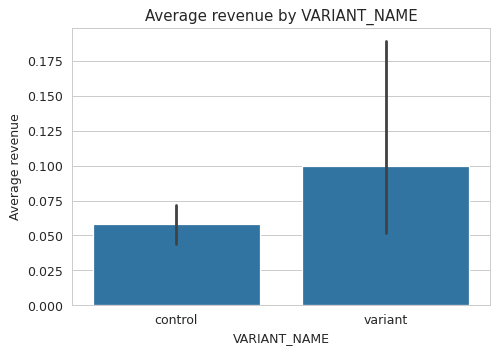

In [8]:
# Bar plot of average revenue by group
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="VARIANT_NAME", y="REVENUE", errorbar=("ci", 95))
plt.title("Average revenue by VARIANT_NAME")
plt.ylabel("Average revenue")
plt.show()
